In [ ]:
#libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, RidgeCV, Lasso
from sklearn.preprocessing import StandardScaler
# from sklearn.datasets import load_boston

#data
boston_df = pd.read_csv("BostonHousing.csv")
boston_df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


<Axes: >

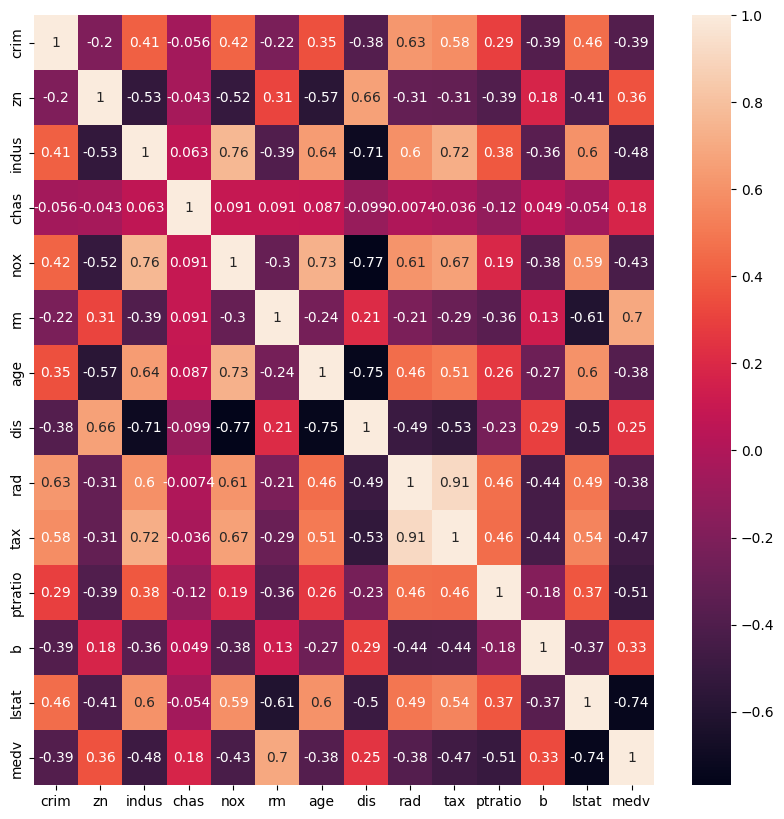

In [ ]:
#Exploration
plt.figure(figsize = (10, 10))
sns.heatmap(boston_df.corr(), annot = True)

In [ ]:
#There are cases of multicolinearity, we will drop a few columns
boston_df.drop(columns = ["indus", "nox"], inplace = True)




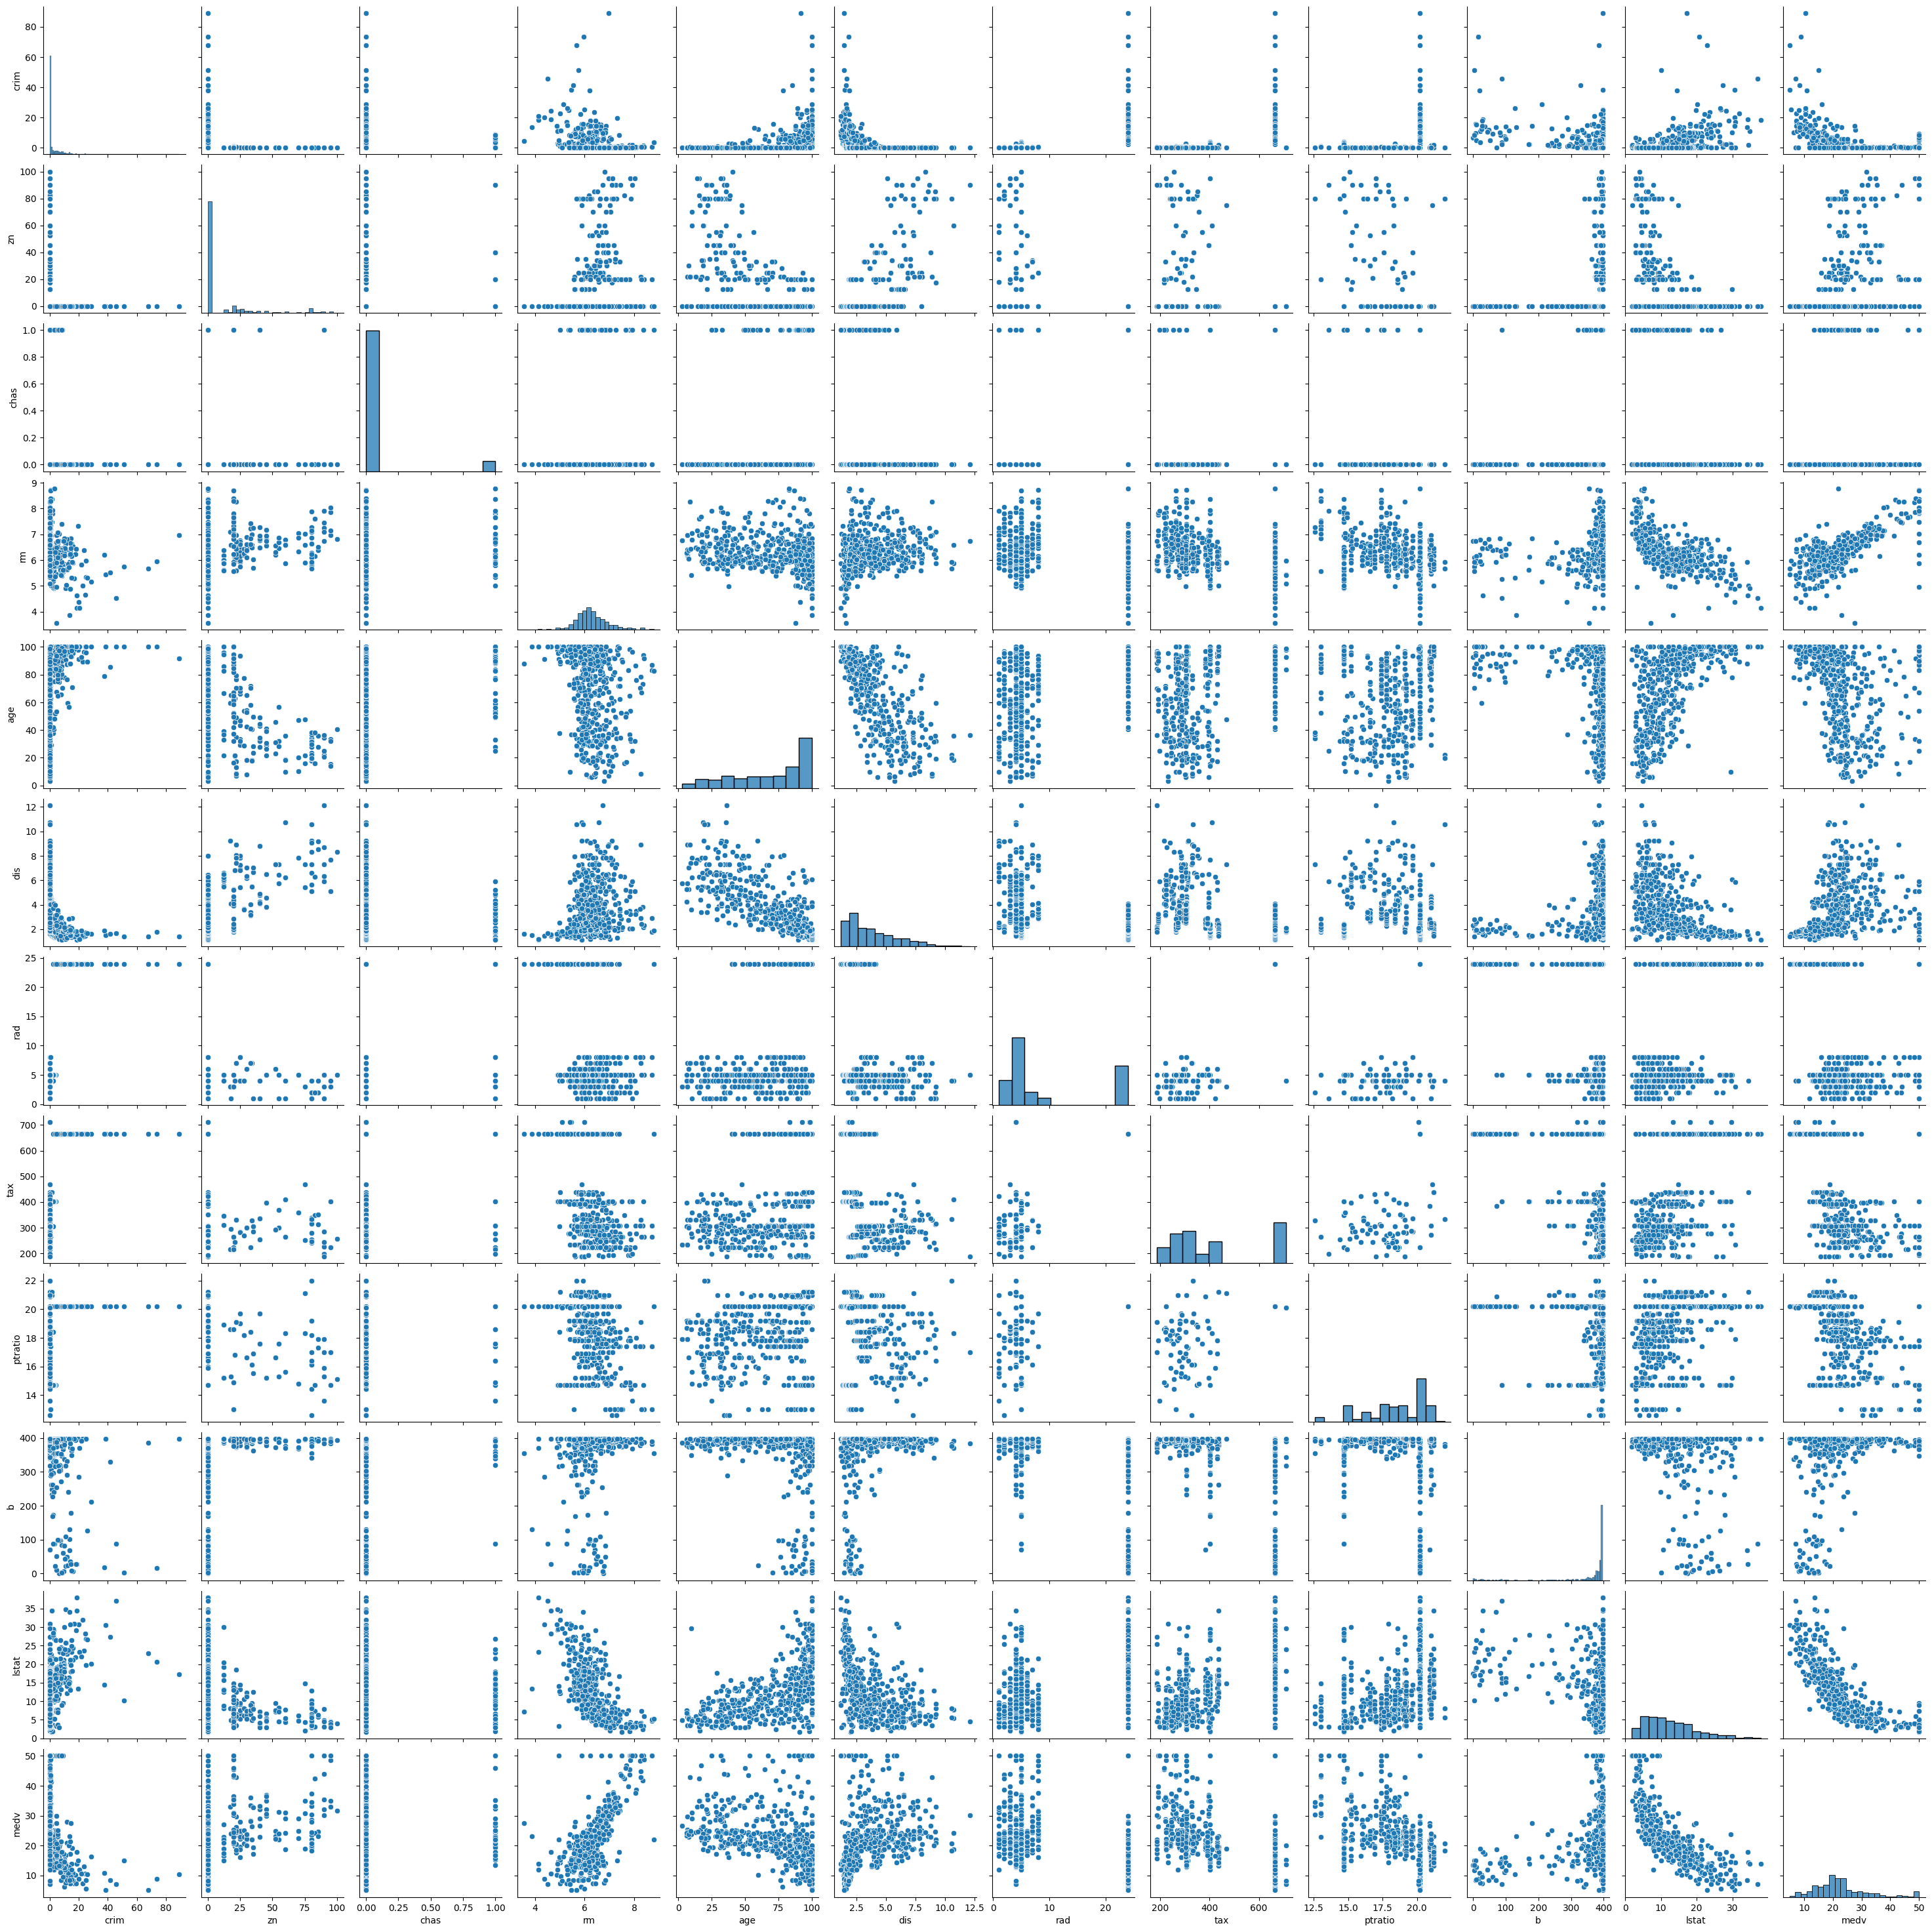

In [ ]:
#pairplot
sns.pairplot(boston_df)

#we will log the LSTAT Column
boston_df.lstat = np.log(boston_df.lstat)

In [ ]:
#preview
featu=res  boston_df.columns[0:11]
target = boston_df.columns[-1]

#X and y values
X = boston_df[features].values
y = boston_df[target].values

#splot
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=17)

print("The dimension of X_train is {}".format(X_train.shape))
print("The dimension of X_test is {}".format(X_test.shape))
#Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


The dimension of X_train is (354, 11)
The dimension of X_test is (152, 11)


In [ ]:
#Model
lr = LinearRegression()

#Fit model
lr.fit(X_train, y_train)

#predict
#prediction = lr.predict(X_test)

#actual
actual = y_test

train_score_lr = lr.score(X_train, y_train)
test_score_lr = lr.score(X_test, y_test)

print("The train score for lr model is {}".format(train_score_lr))
print("The test score for lr model is {}".format(test_score_lr))



The train score for lr model is 0.7859187129718976
The test score for lr model is 0.7672379770848983


In [ ]:
#Ridge Regression Model
ridgeReg = Ridge(alpha=10)

ridgeReg.fit(X_train,y_train)

#train and test scorefor ridge regression
train_score_ridge = ridgeReg.score(X_train, y_train)
test_score_ridge = ridgeReg.score(X_test, y_test)

print("\nRidge Model............................................\n")
print("The train score for ridge model is {}".format(train_score_ridge))
print("The test score for ridge model is {}".format(test_score_ridge))


Ridge Model............................................

The train score for ridge model is 0.7844233397895741
The test score for ridge model is 0.7696722158755337


In [ ]:
#Lasso regression model
print("\nLasso Model............................................\n")
lasso = Lasso(alpha = 10)
lasso.fit(X_train,y_train)
train_score_ls =lasso.score(X_train,y_train)
test_score_ls =lasso.score(X_test,y_test)

print("The train score for ls model is {}".format(train_score_ls))
print("The test score for ls model is {}".format(test_score_ls))



Lasso Model............................................

The train score for ls model is 0.0
The test score for ls model is -0.0030704836212473996


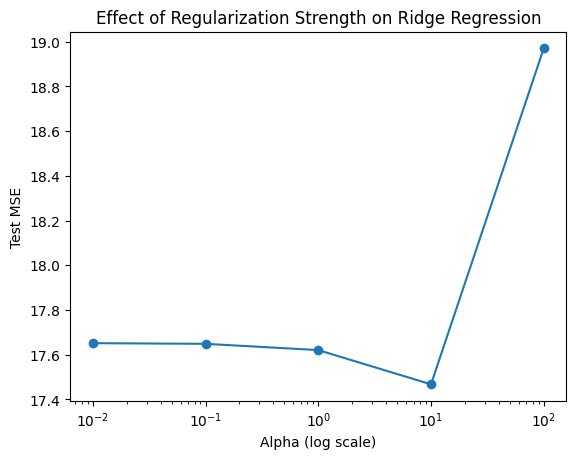

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score


# Try different alpha values for Ridge
alphas = [0.01, 0.1, 1, 10, 100]
ridge_mse = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)

    y_test_pred = ridge.predict(X_test)
    mse = mean_squared_error(y_test, y_test_pred)
    ridge_mse.append(mse)

# Plot results
plt.plot(alphas, ridge_mse, marker='o')
plt.xscale('log')
plt.xlabel("Alpha (log scale)")
plt.ylabel("Test MSE")
plt.title("Effect of Regularization Strength on Ridge Regression")
plt.show()


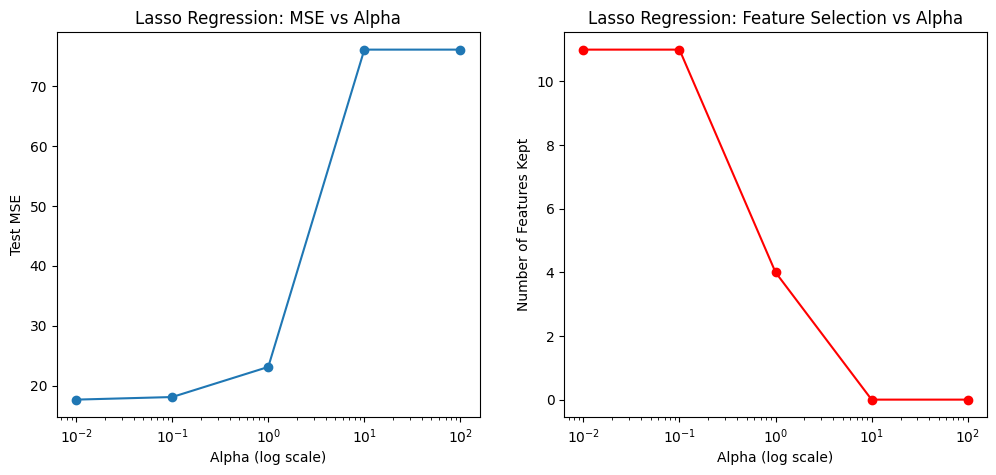

In [ ]:
# Try different alpha values for Lasso
lasso_mse = []
num_features = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)

    y_test_pred = lasso.predict(X_test)
    mse = mean_squared_error(y_test, y_test_pred)

    lasso_mse.append(mse)
    num_features.append(np.sum(lasso.coef_ != 0))  # Count non-zero coefficients

# Plot MSE vs Alpha
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(alphas, lasso_mse, marker='o', label='MSE')
plt.xscale('log')
plt.xlabel("Alpha (log scale)")
plt.ylabel("Test MSE")
plt.title("Lasso Regression: MSE vs Alpha")

plt.subplot(1,2,2)
plt.plot(alphas, num_features, marker='o', color='red', label='Num Features')
plt.xscale('log')
plt.xlabel("Alpha (log scale)")
plt.ylabel("Number of Features Kept")
plt.title("Lasso Regression: Feature Selection vs Alpha")

plt.show()


In [ ]:
# Try different alpha values
alphas = [0.01, 0.1, 1, 10, 100]

ridge_coefs = []
lasso_coefs = []

for alpha in alphas:
    # Ridge Regression
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    ridge_coefs.append(ridge.coef_)  # Store coefficients

    # Lasso Regression
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)
    lasso_coefs.append(lasso.coef_)  # Store coefficients

# Convert to numpy arrays for visualization
ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)


In [ ]:
# Print coefficients for Ridge
print("Ridge Coefficients:")
for i, alpha in enumerate(alphas):
    print(f"Alpha = {alpha}: {ridge_coefs[i]}")

print("\nLasso Coefficients:")
for i, alpha in enumerate(alphas):
    print(f"Alpha = {alpha}: {lasso_coefs[i]}")


Ridge Coefficients:
Alpha = 0.01: [-1.10307009  0.47555056  0.67892287  1.47151636  0.42056352 -1.86914616
  2.45363496 -2.31812531 -1.50337782  0.69412636 -6.27737247]
Alpha = 0.1: [-1.10204106  0.47485784  0.67959941  1.47363989  0.41875276 -1.86737459
  2.44605148 -2.31102674 -1.5032489   0.69425177 -6.27328183]
Alpha = 1: [-1.09204109  0.46818542  0.68620297  1.49440804  0.40103304 -1.84998558
  2.37261442 -2.24244735 -1.50196928  0.69548519 -6.23283036]
Alpha = 10: [-1.01385344  0.42046646  0.73945596  1.66403414  0.2553313  -1.70099719
  1.81780325 -1.73622109 -1.48971734  0.70571772 -5.86847331]
Alpha = 100: [-0.76213407  0.36869393  0.87946813  2.09240986 -0.21311295 -0.95735969
  0.41758008 -0.69821879 -1.36635934  0.70082321 -4.02222414]

Lasso Coefficients:
Alpha = 0.01: [-1.07303971  0.43636904  0.68072553  1.48321467  0.39149393 -1.82909714
  2.32078017 -2.1907083  -1.49957217  0.6815288  -6.26433483]
Alpha = 0.1: [-0.80531316  0.08381168  0.6970215   1.58942098  0.1276804

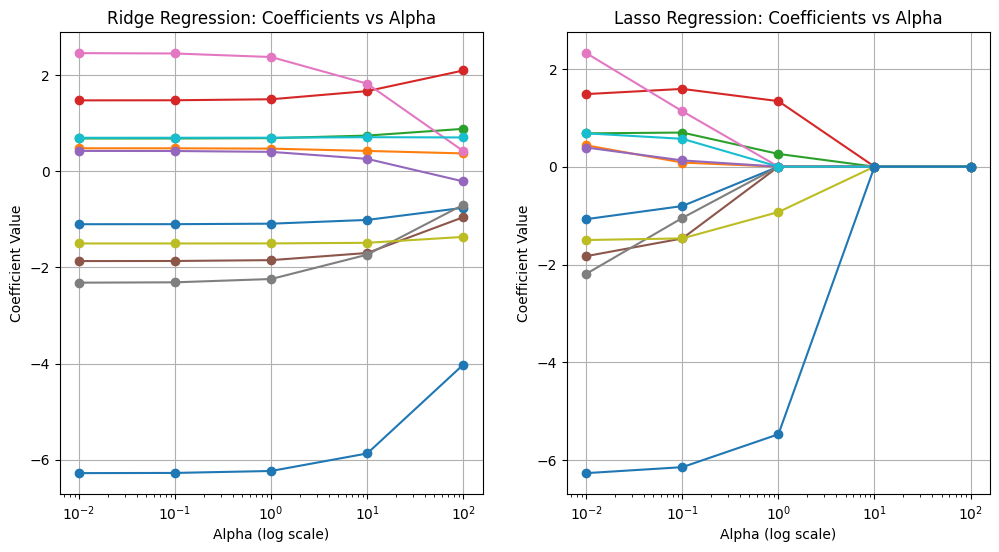

In [ ]:
plt.figure(figsize=(12, 6))

# Ridge Coefficients Plot
plt.subplot(1, 2, 1)
plt.plot(alphas, ridge_coefs, marker='o')
plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Coefficient Value")
plt.title("Ridge Regression: Coefficients vs Alpha")
plt.grid(True)

# Lasso Coefficients Plot
plt.subplot(1, 2, 2)
plt.plot(alphas, lasso_coefs, marker='o')
plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Coefficient Value")
plt.title("Lasso Regression: Coefficients vs Alpha")
plt.grid(True)

plt.show()
